In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

## Data Analysis

In [3]:
data = pd.read_csv("/content/Employee-Attrition-Project.csv")


# ================================ Data Analysis ==================================

print("Top 10 Employees Data: \n",data.head(10))

print("\nNumber of Employees: \t",data.shape[0])
print("Number of Features: \t",data.shape[1])

print("\nChecking 'Data type' stored in each feature: ")
print(data.info())

Top 10 Employees Data: 
    Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes  ...                       0                     5
1   49        No  ...                       1                     7
2   37       Yes  ...                       0                     0
3   33        No  ...                       3                     0
4   27        No  ...                       2                     2
5   32        No  ...                       3                     6
6   59        No  ...                       0                     0
7   30        No  ...                       0                     0
8   38        No  ...                       1                     8
9   36        No  ...                       7                     7

[10 rows x 35 columns]

Number of Employees: 	 1470
Number of Features: 	 35

Checking 'Data type' stored in each feature: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 colum

## Data Cleaning

In [4]:
# ================================ Data Cleaning ==================================

print("\nChecking for 'Null/Missing value' in Data Set: \n",data.isnull().sum())
# There is not a single Null/Missing value in whole data

print("\nChecking for 'Duplicate value' in Data Set: \n",data.duplicated().sum(),"\n")
# In the Data Set there is not a Duplicate data



Checking for 'Null/Missing value' in Data Set: 
 Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany      

## EDA(Exploratory Data Analysis) on "Attrition"

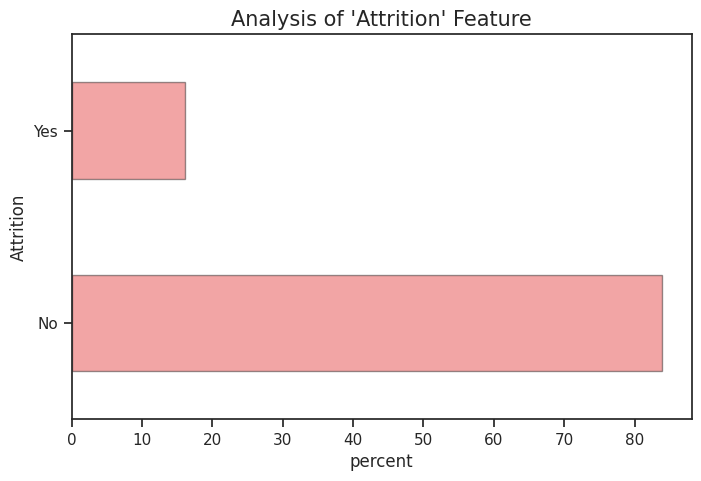


Total Numbers of Employee who 'not want to leave the company': 	 1233
Total Numbers of Employee who 'want to leave the company': 	 237 




In [5]:
# =================== EDA(Exploratary Data Analysis) on "Attrition" =================

sns.set(style = "ticks")

plt.figure(figsize = (8,5))

plt.title("Analysis of 'Attrition' Feature",fontsize = 15)


sns.countplot(y = "Attrition",data = data,color = "red",edgecolor = "black",width = 0.5,stat = "percent",alpha = 0.4)
plt.show()

print("\nTotal Numbers of Employee who 'not want to leave the company': \t",data["Attrition"].value_counts().iloc[0])
print("Total Numbers of Employee who 'want to leave the company': \t",data["Attrition"].value_counts().iloc[1],"\n\n")


#  I hypothesize that employee attrition was influnced by: Age , MaritalStatus , DistanceFromHome ,
                                                          #  MonthlyIncome , JobRole , EnvironmentSatisfaction ,
                                                          #  NumCompaniesWorked , Department


## Data Insights from "Attrition and Job_Role Feature"

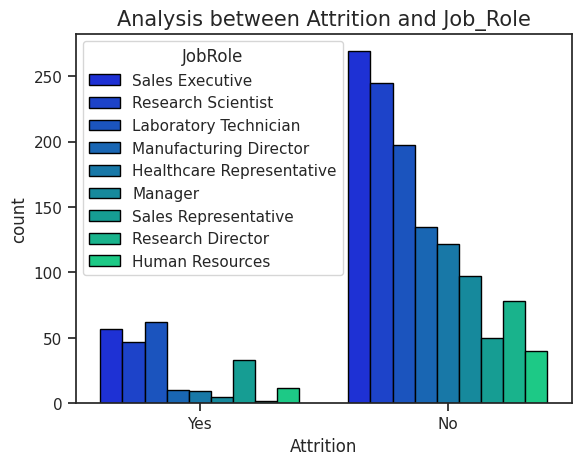


According to Data , Company should focus on "Sales Representative" job role
due to approx 50 percent of "Sales Representative" Employees want to leave the company.
Whereas the Others job role there was not a major percent of leaving the company.




In [6]:
# =================== Data Insights from "Attrition and Job_Role Feature" ======================


plt.title("Analysis between Attrition and Job_Role",fontsize = 15)


sns.countplot(x = "Attrition",data = data,hue = "JobRole",palette = "winter",edgecolor = "black",stat = "count")
plt.show()

print("""\nAccording to Data , Company should focus on "Sales Representative" job role
due to approx 50 percent of "Sales Representative" Employees want to leave the company.
Whereas the Others job role there was not a major percent of leaving the company.\n\n""")



## Analysis between "Attrition and Marital_Status"

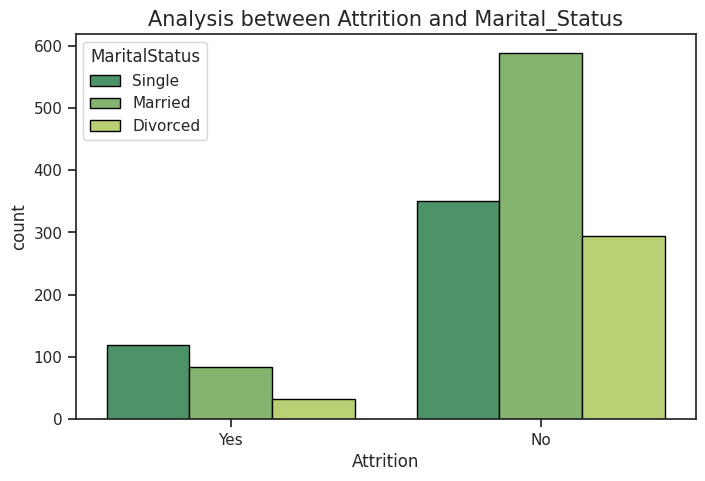


According to Data, Maritial Status was 'not a major factor' for Employees to leave the Company.


In [7]:
# ==================== Analysis between "Attrition and Marital_Status" ========================

plt.figure(figsize = (8,5))

plt.title("Analysis between Attrition and Marital_Status",fontsize = 15)


sns.countplot(x = "Attrition",data = data,hue = "MaritalStatus",palette = "summer",edgecolor = "black")
plt.show()

print("\nAccording to Data, Maritial Status was 'not a major factor' for Employees to leave the Company.")



## Comparision between "Attrition and Department"

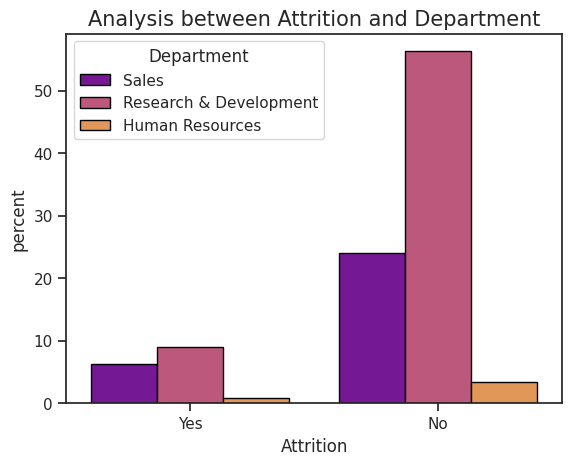


The Company should focus on the Sales Department due to according to data
form Sales Department approx 25 to 30 percent of Employees want to leave the Company.




In [8]:
# ==================== Comparision between "Attrition and Department" ========================

plt.title("Analysis between Attrition and Department",fontsize = 15)

sns.countplot(x = "Attrition",data = data,hue = "Department",palette = "plasma",stat = "percent",edgecolor = "black")
plt.show()

print("""\nThe Company should focus on the Sales Department due to according to data
form Sales Department approx 25 to 30 percent of Employees want to leave the Company.\n\n""")



## Analysis Between "Attrition and Distance_From_Home"

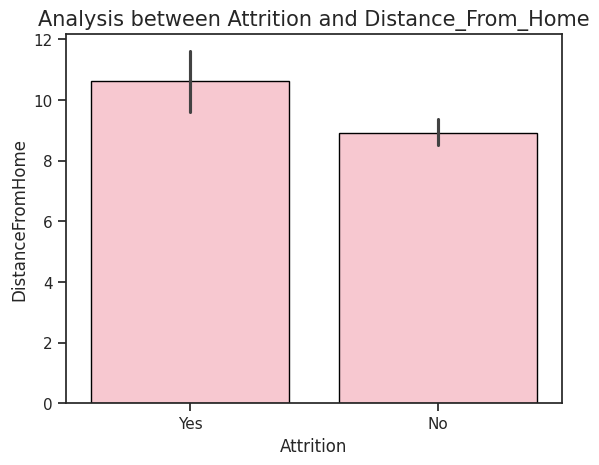


Those Employees who having more distance from their home were like to leave the company.
Company should assign as remote work to those employees who having more distance from their home




In [9]:
# ================= Analysis Between "Attrition and Distance_From_Home" ========================


plt.title("Analysis between Attrition and Distance_From_Home",fontsize = 15)


sns.barplot(x = "Attrition",y = "DistanceFromHome",data = data,color = "pink",estimator = "mean",edgecolor = "black")
plt.show()


print( """\nThose Employees who having more distance from their home were like to leave the company.
Company should assign as remote work to those employees who having more distance from their home\n\n""")



## Analysis between "Attrition and Monthly_Income"

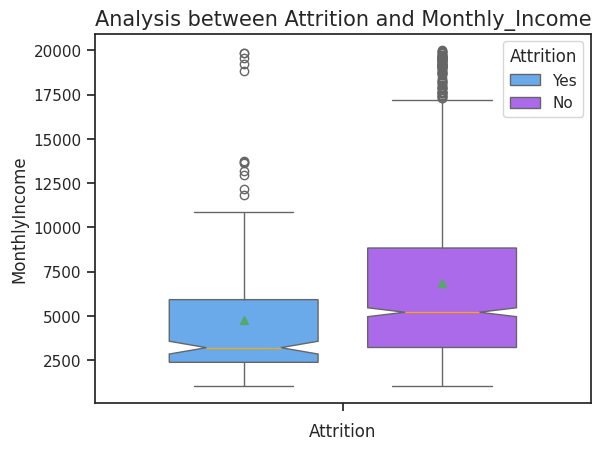


Those Employees like to leave the company were who getting less/lower monthly salary.
Company should increase the monthly salary for those who having less monthly salary and also company wanted to them.




In [10]:
# ================= Analysis between "Attrition and Monthly_Income" =====================

plt.title("Analysis between Attrition and Monthly_Income",fontsize = 15)

plt.xlabel("Attrition")

sns.boxplot(y = "MonthlyIncome",data = data,hue = "Attrition",palette = "cool",notch = True,showmeans = True,widths = 0.3,medianprops = dict(color = "orange",linewidth = 0.9))
plt.show()

print("""\nThose Employees like to leave the company were who getting less/lower monthly salary.
Company should increase the monthly salary for those who having less monthly salary and also company wanted to them.\n\n""")



## Comparison between "Attrition and Environment_Satisfaction"

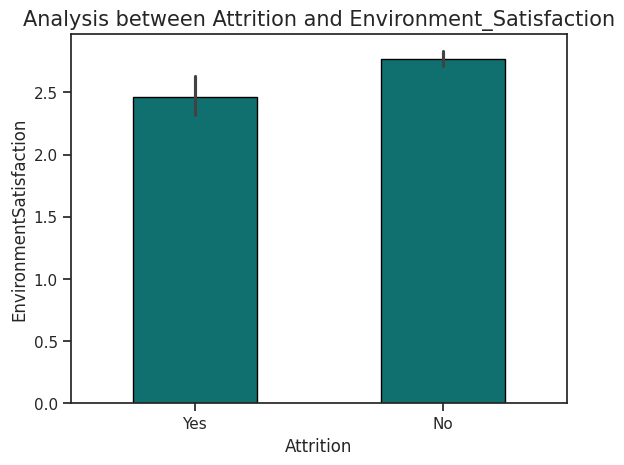


Those Employees who are not satisfy with their surrounding environment were like to leave the company.
Company should take care and make improvement on the surrounding environment.




In [11]:
# ================= Comaprision between "Attrition and Environment_Satisfaction" =====================

plt.title("Analysis between Attrition and Environment_Satisfaction",fontsize = 15)


sns.barplot(x = "Attrition",y = "EnvironmentSatisfaction",data = data,estimator = np.mean,errorbar = "ci",color = "teal",edgecolor = "black",width = 0.5)
plt.show()


print("""\nThose Employees who are not satisfy with their surrounding environment were like to leave the company.
Company should take care and make improvement on the surrounding environment.\n\n""")



## Data Insights from "Attrition and Years_At_Company"

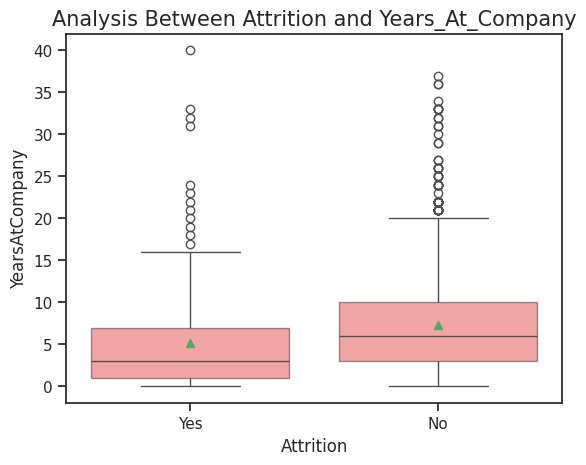


According to Data, Most of the New Employees were like to leave the company.
Company should focus on Young Employees and ask them to 'why they want to leave the company ?' and
focus on major issue for them.




In [12]:
# ================= Data Insights from "Attrition and Years_At_Company" =====================


plt.title("Analysis Between Attrition and Years_At_Company",fontsize = 15)

sns.boxplot(x = "Attrition",y = "YearsAtCompany",data = data,color = "red",boxprops = dict(alpha = 0.4,edgecolor = "black"),showmeans = True)
plt.show()

print("""\nAccording to Data, Most of the New Employees were like to leave the company.
Company should focus on Young Employees and ask them to 'why they want to leave the company ?' and
focus on major issue for them.\n\n""")



## Data Encoding

In [13]:
# ==================================== Data Encoding ===================================


for val in data.select_dtypes(include = "object").columns:
  data[val] = data[val].astype("category")

print(data.dtypes)

data = pd.get_dummies(data,columns = data.select_dtypes(include = "category").columns,drop_first = True)
# print(data.columns)


Age                            int64
Attrition                   category
BusinessTravel              category
DailyRate                      int64
Department                  category
DistanceFromHome               int64
Education                      int64
EducationField              category
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                      category
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                     category
JobSatisfaction                int64
MaritalStatus               category
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                      category
OverTime                    category
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

## Data Selection

In [14]:
# ==================================== Data Selection ===================================

# After Data Encoding,
#  "Attrition" feature name were changes to "Attrition_Yes"

X = data.drop("Attrition_Yes",axis = 1)

y = data["Attrition_Yes"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)


## Data Prediction using Logistic Regression

In [18]:
# ==================================== Data Prediction using Logistic Regression ===================================


logis_model = LogisticRegression(class_weight = "balanced",solver = "sag",max_iter = 10000,random_state = 42)

logis_model.fit(X_train,y_train)

pred_data = logis_model.predict(X_test)
log_prob_predict = logis_model.predict_proba(X_test)
# print(log_prob_predict)

acc_logistic = accuracy_score(y_test,pred_data)
print("\nAccuracy of Predicted Data in percent: \n",acc_logistic*100)


cm = confusion_matrix(y_test,pred_data)
print("\nModel Prediction Report of Logistic Regression: \n", pd.DataFrame(dict(Predicted_Stay = cm[:,0],
                                                       Predicted_Leave = cm[:,1]),index = ["Actual_Stay","Actual_Leave"]))

cr = classification_report(y_test,pred_data)
print("\nClassification Report of Logistic Regression: \n",cr)




Accuracy of Predicted Data in percent: 
 59.013605442176875

Model Prediction Report of Logistic Regression: 
               Predicted_Stay  Predicted_Leave
Actual_Stay              295              212
Actual_Leave              29               52

Classification Report of Logistic Regression: 
               precision    recall  f1-score   support

       False       0.91      0.58      0.71       507
        True       0.20      0.64      0.30        81

    accuracy                           0.59       588
   macro avg       0.55      0.61      0.51       588
weighted avg       0.81      0.59      0.65       588



## Decision Tree Model

In [19]:
# ============================ Decison Tree Model ================================


tree_model = DecisionTreeClassifier(max_depth = 8,criterion = "entropy",random_state = 42)

tree_model.fit(X_train,y_train)

pred_data = tree_model.predict(X_test)
# print(pred_data)

acc_tree = accuracy_score(y_test,pred_data)

print("\n\nAccuracy of Tree: \n",acc_tree)
print("\nConfusion Matrix of Tree: \n",pd.DataFrame(dict(Predicted_stay = confusion_matrix(y_test,pred_data)[:,0],
                                               Predicted_leave = confusion_matrix(y_test,pred_data)[:,1]),index = ["Actual_stay","Actual_leave"]))
print("\nClassification Report of Tree: \n",classification_report(y_test,pred_data))





Accuracy of Tree: 
 0.8299319727891157

Confusion Matrix of Tree: 
               Predicted_stay  Predicted_leave
Actual_stay              465               42
Actual_leave              58               23

Classification Report of Tree: 
               precision    recall  f1-score   support

       False       0.89      0.92      0.90       507
        True       0.35      0.28      0.32        81

    accuracy                           0.83       588
   macro avg       0.62      0.60      0.61       588
weighted avg       0.82      0.83      0.82       588



## Random Forest Model

In [20]:
# =================================== Random Forest Model ==========================================


forest_model = RandomForestClassifier(n_estimators = 200,random_state = 42)

forest_model.fit(X_train,y_train)

pred_data = forest_model.predict(X_test)

acc_forest = accuracy_score(y_test,pred_data)

print("\n\nAccuracy of Forest: \n",acc_forest)
print("\nConfusion Matrix of Forest: \n",pd.DataFrame(dict(Predicted_stay = confusion_matrix(y_test,pred_data)[:,0],
                                               Predicted_leave = confusion_matrix(y_test,pred_data)[:,1]),index = ["Actual_stay","Actual_leave"]))
print("\nClassification Report of Forest: \n",classification_report(y_test,pred_data))





Accuracy of Forest: 
 0.8724489795918368

Confusion Matrix of Forest: 
               Predicted_stay  Predicted_leave
Actual_stay              504                3
Actual_leave              72                9

Classification Report of Forest: 
               precision    recall  f1-score   support

       False       0.88      0.99      0.93       507
        True       0.75      0.11      0.19        81

    accuracy                           0.87       588
   macro avg       0.81      0.55      0.56       588
weighted avg       0.86      0.87      0.83       588



### Acc Comparision Between Logistic Reg. , Decision Tree and Random Forest

In [22]:
# ===================== Acc Comparision Between Logistic Reg. , Decision Tree and Random Forest ====================

acc_comp = pd.DataFrame(dict(Model = ["Logistic_Regression","Decision_Tree","Random_Forest"],
                             Acc_Score = [acc_logistic,acc_tree,acc_forest]))

print("Accuracy Comparision: \n",acc_comp)


Accuracy Comparision: 
                  Model  Acc_Score
0  Logistic_Regression   0.590136
1        Decision_Tree   0.829932
2        Random_Forest   0.872449


## Factors which make Employees to leave the company

In [23]:
# ========================== Factors which make Employees to leave the company =================================

maj_fac = pd.DataFrame(dict(Features = X.columns,
                            Importance = forest_model.feature_importances_)).sort_values(by = "Importance",ascending = False)

print("\nMajor factors that make employee to leave the company: \n",maj_fac.head(10))



Major factors that make employee to leave the company: 
              Features  Importance
11      MonthlyIncome    0.068736
0                 Age    0.051681
5      EmployeeNumber    0.046948
19  TotalWorkingYears    0.046780
46       OverTime_Yes    0.046693
7          HourlyRate    0.046494
2    DistanceFromHome    0.046375
1           DailyRate    0.046219
12        MonthlyRate    0.044394
22     YearsAtCompany    0.041796
